# Introduction to Convolutional Neural Networks and Computer Vision with TensorFlow

Computer vision is the practice of writing algorithms which can discover patterns in visual data . Such as the camera of a self-driving car recognizing the car in front .

The images we're working with are from the Food101 dataset from Kaggle .

However is modified to only use two classes (pizza 🍕 & steak 🥩)

In [1]:
import zipfile

# Get the data 
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip 

# Unzip the downloaded file 
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

--2026-01-12 17:12:19--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.200.207, 74.125.130.207, 74.125.68.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.200.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M  22.5MB/s    in 6.0s    

2026-01-12 17:12:25 (17.5 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



Inspect the data

In [2]:
!ls pizza_steak

test  train


In [3]:
!ls pizza_steak/train

pizza  steak


In [4]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [5]:
import os 

# Walk through pizza_steak directory and list number of files
for dirpath , dirname , filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'")

There are 2 directories and 0 images in 'pizza_steak'
There are 2 directories and 0 images in 'pizza_steak/test'
There are 0 directories and 250 images in 'pizza_steak/test/steak'
There are 0 directories and 250 images in 'pizza_steak/test/pizza'
There are 2 directories and 0 images in 'pizza_steak/train'
There are 0 directories and 750 images in 'pizza_steak/train/steak'
There are 0 directories and 750 images in 'pizza_steak/train/pizza'


In [6]:
# Another way to find out how many images are in a file 
num_steak_images = len(os.listdir("pizza_steak/train/steak"))

num_steak_images

750

To visualize our images , first let's get the class names programmatically .

In [7]:
# Get the class names programmatically
import pathlib
import numpy as np

data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Create a list of class names from the subdirectories 

print(class_names)

['pizza' 'steak']


In [8]:
# Let's visualize our images
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import random

def view_random_image(target_dir , target_class) :
    # Setup the target dir 
    target_folder = target_dir + target_class
    
    # Get random image 
    random_image = random.sample(os.listdir(target_folder),1)
    
    # Read in the image and plot it using matplotlib
    img = mpimg.imread(target_folder + "/" + random_image[0])
    
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    print(f"Image shape: {img.shape}") # show the shape of the image
    
    return img

Image shape: (512, 512, 3)


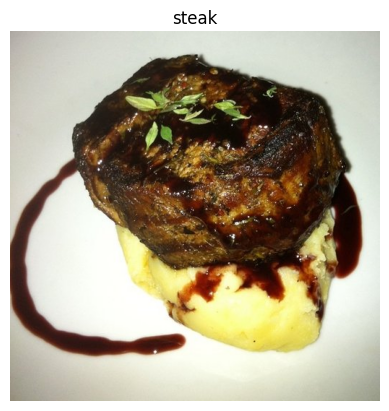

In [9]:
# View a random image from the training dataset
img = view_random_image("pizza_steak/train/" , "steak")

Image shape: (512, 512, 3)


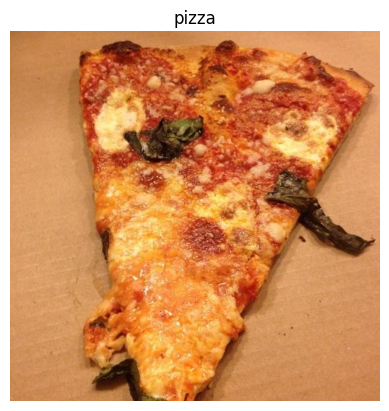

In [10]:
img2 = view_random_image("pizza_steak/train/", "pizza")

In [11]:
import tensorflow as tf 

tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[170, 165, 159],
        [170, 165, 159],
        [171, 166, 160],
        ...,
        [182, 185, 176],
        [181, 184, 175],
        [180, 183, 174]],

       [[171, 166, 160],
        [171, 166, 160],
        [172, 167, 161],
        ...,
        [183, 186, 177],
        [182, 185, 176],
        [181, 184, 175]],

       [[172, 167, 161],
        [172, 167, 161],
        [174, 169, 163],
        ...,
        [184, 187, 178],
        [183, 186, 177],
        [183, 186, 177]],

       ...,

       [[148, 141, 123],
        [149, 142, 124],
        [149, 142, 124],
        ...,
        [150, 153, 134],
        [151, 154, 135],
        [153, 156, 137]],

       [[147, 140, 122],
        [148, 141, 123],
        [149, 142, 124],
        ...,
        [148, 151, 132],
        [148, 151, 132],
        [151, 154, 135]],

       [[146, 139, 121],
        [148, 141, 123],
        [150, 143, 125],
        ...,
        [147, 150, 13

In [12]:
# View the image shape 
img.shape # returns width , height , color_channels


(512, 512, 3)

## An end-to-end example 

Let's build a convolutional neural network to find patterns in our images , more specifically we a need way to :

* Load our iamges 
* Preprocess our images 
* Build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNN to our training data 

In [13]:
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed 
tf.random.set_seed(42)

# Preprocess the data (get all of the pixel values between 0 and 1)
train_datagen = ImageDataGenerator(rescale=1./255.)
valid_datagen = ImageDataGenerator(rescale=1./255.)

# Import data from directories and turn it into batches 
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size=(244,244),
                                               class_mode="binary",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(244,244),
                                               class_mode="binary",
                                               seed=42)

# Build a CNN model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10 , 
                           kernel_size=3 ,
                           activation="relu",
                           input_shape=(244,244,3)),
    tf.keras.layers.Conv2D(10 , 3 , activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2 , padding="valid"),
    tf.keras.layers.Conv2D(10 , 3 , activation="relu"),
    tf.keras.layers.Conv2D(10 , 3 , activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1 , activation="sigmoid")
])

# Compile our CNN
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 245ms/step - accuracy: 0.5894 - loss: 0.6599 - val_accuracy: 0.8020 - val_loss: 0.4183
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.7963 - loss: 0.4419 - val_accuracy: 0.8640 - val_loss: 0.3244
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.8423 - loss: 0.3714 - val_accuracy: 0.8520 - val_loss: 0.3217
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8651 - loss: 0.3265 - val_accuracy: 0.8780 - val_loss: 0.3100
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.8757 - loss: 0.3019 - val_accuracy: 0.8560 - val_loss: 0.3431


In [15]:
# Get a model summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 242, 242, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 240, 240, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 120, 120, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 118, 118, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 116, 116, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 58, 58, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33640)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        33,641 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,955 (429.52 KB)

 Trainable params: 36,651 (143.17 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 73,304 (286.35 KB)

In [16]:
# Set random seed
tf.random.set_seed(42)

# Create a model 
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(244,244,3)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1 , activation="sigmoid")
])

# Compile the model
model_2.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.5127 - loss: 1.6572 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.4857 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.5098 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.5094 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5353 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6932


In [17]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 178608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │       714,436 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,143,385 (8.18 MB)

 Trainable params: 714,461 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,428,924 (5.45 MB)

In [18]:
# Set random seed
tf.random.set_seed(42)

# Create a model 
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(244,244,3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1 , activation="sigmoid")
])

# Compile the model
model_3.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.5453 - loss: 8.5819 - val_accuracy: 0.7180 - val_loss: 1.5039
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.7007 - loss: 1.3685 - val_accuracy: 0.7880 - val_loss: 0.5539
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.7331 - loss: 0.6456 - val_accuracy: 0.7820 - val_loss: 0.5811
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.7643 - loss: 0.5852 - val_accuracy: 0.7660 - val_loss: 0.4971
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.7941 - loss: 0.5359 - val_accuracy: 0.8100 - val_loss: 0.4447


In [19]:
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 178608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │    17,860,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,643,605 (204.63 MB)

 Trainable params: 17,881,201 (68.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,762,404 (136.42 MB)

## Binary Classification : Let's break it down

1. Understand the data (visualize)
2. Prepocess the data (prepared it for our model)
3. Created a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve the model (try to beat our baseline)
7. Repeat until satisfied (experiment)

Image shape: (512, 512, 3)
Image shape: (512, 341, 3)


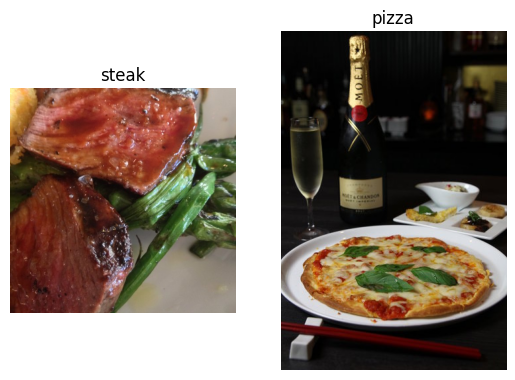

In [20]:
# Visualize data
plt.figure()
plt.subplot(1 , 2, 1)
steak_img = view_random_image("pizza_steak/train/" , "steak")
plt.subplot(1 , 2 , 2)
pizza_img = view_random_image("pizza_steak/train/" , "pizza")

In [ ]:
# Preprocess the data 

# Define directory dataset paths
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

In [22]:
# Turn data into batches
# Create train and test data generators and rescale the data 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255.)
test_datagen = ImageDataGenerator(rescale=1./255.)

# Load in our image data from directories and turn them into batches
train_data = train_datagen.flow_from_directory(directory=train_dir, # Target dir of images
                                               target_size=(244,244), # Target size of images
                                               class_mode="binary", # Type of data you're working with
                                               batch_size=32) # size of mini-batches to load data into

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(244,244),
                                             class_mode="binary",
                                             batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [23]:
# Get a sample of a train data batch
images , labels = next(train_data) # get next batch of images and labels
len(images) , len(labels)

(32, 32)

In [24]:
# Get the first 2 images
images[:2] , images[0].shape

(array([[[[0.56078434, 0.63529414, 0.79215693],
          [0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5647059 , 0.6392157 , 0.7960785 ],
          ...,
          [0.05882353, 0.0627451 , 0.04313726],
          [0.08235294, 0.08235294, 0.07450981],
          [0.09803922, 0.09803922, 0.09803922]],
 
         [[0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          ...,
          [0.06666667, 0.07058824, 0.04705883],
          [0.0627451 , 0.06666667, 0.04705883],
          [0.04313726, 0.04313726, 0.03529412]],
 
         [[0.5686275 , 0.6431373 , 0.8078432 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          [0.5647059 , 0.6392157 , 0.80392164],
          ...,
          [0.10196079, 0.10588236, 0.08235294],
          [0.15686275, 0.16078432, 0.13725491],
          [0.21568629, 0.21960786, 0.20000002]],
 
         ...,
 
         [[0.3921569 , 0.34901962, 0.22352943],
          [0.39607

In [25]:
# View the first batch of labels
labels

array([0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.],
      dtype=float32)

In [26]:
# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense , Flatten , Conv2D , MaxPool2D , Activation
from tensorflow.keras import Sequential    

In [27]:
# Create the model
model_4 = Sequential([
    Conv2D(filters=10, # filter is the number of sliding windows going across an input (higher - more complex)
           kernel_size=3 , # the size of the sliding window going across an input 
           strides=1 , # the size of the step the sliding window takes across an input
           padding="valid" , # If "same" , output shape is same as input shape , if "valid" is compressed
           activation="relu", 
           input_shape=(244,244,3)), # Input layer
    Conv2D(10,3, activation="relu"),                    
    Conv2D(10,3, activation="relu"),
    Flatten(),
    Dense(1 , activation="sigmoid") # Output layer
])

In [28]:
# Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

In [ ]:
# Fit the model
len(train_data) , len(test_data)

(47, 16)

In [30]:
# Fit the model
history_4 = model_4.fit(train_data , # this is a combionations of labels and sample data
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 220ms/step - accuracy: 0.5397 - loss: 2.3568 - val_accuracy: 0.7180 - val_loss: 0.6476
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8114 - loss: 0.5393 - val_accuracy: 0.8340 - val_loss: 0.4095
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8823 - loss: 0.3315 - val_accuracy: 0.8300 - val_loss: 0.4069
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.9405 - loss: 0.2152 - val_accuracy: 0.7840 - val_loss: 0.4307
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.9754 - loss: 0.1188 - val_accuracy: 0.8080 - val_loss: 0.4118


<Axes: >

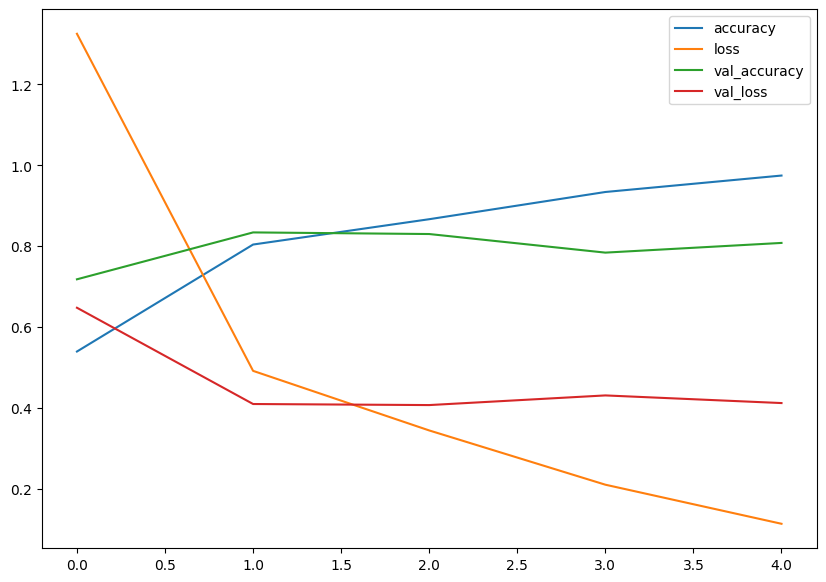

In [31]:
# Evaluate the model
import pandas as pd

pd.DataFrame(history_4.history).plot(figsize=(10,7))

In [32]:
# Plot the validation and training curves separately
def plot_loss_curves(history) :
    """
       Returns separate loss curves for training and validation metrics . 
    """  
    
    loss = history.history["loss"]
    
    val_loss = history.history["val_loss"]
    
    accuracy = history.history["accuracy"]
    
    val_accuracy = history.history["val_accuracy"]
    
    epochs = range(len(history.history["loss"])) # how many epochs did we run for ?
    
    # Plot loss
    plt.plot(epochs , loss , label = "training_loss")
    plt.plot(epochs , val_loss , label = "val_loss")
    plt.title("loss")
    plt.xlabel("epochs")
    plt.legend()
    
    
    # Plot Accuracy
    plt.figure()
    plt.plot(epochs , accuracy , label = "training_accuracy")
    plt.plot(epochs , val_loss , label = "val_accuracy")
    plt.title("accuracy")
    plt.xlabel("epochs")
    plt.legend();

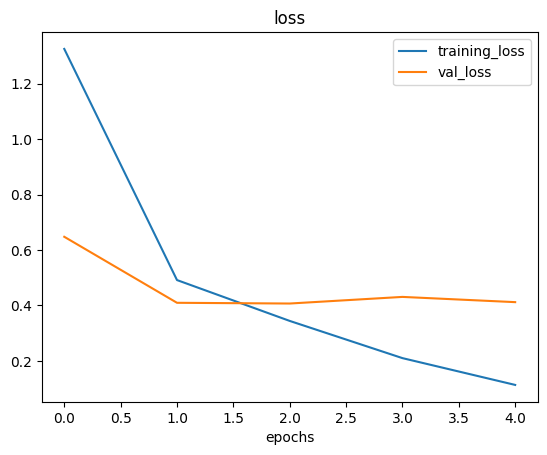

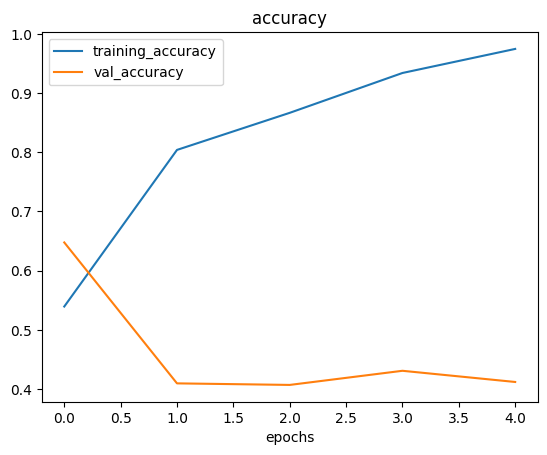

In [33]:
# Check the loss and accuracy
plot_loss_curves(history_4)

### Adjust the model parameters

0. Create a baseline
1. Beat the baseline by overfitting a larger model
2. Reduce overfitting

Ways to induce orverfitting :

* Increase the number of conv layers 
* Increase the number of conv filters
* Add another dense layer to the output of our flattened layer

Reduce Overfitting :

* Add data augumentation
* Add regularization layers (such as MaxPool2D)
* Add more data ...

In [34]:

# Create the model
model_5 = Sequential([
    Conv2D(10,3,activation="relu", input_shape=(244,244,3)),
    MaxPool2D(pool_size=2),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1 , activation="sigmoid")
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# Compile the model
model_5.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

In [36]:
# Fit the model 
history_5 = model_5.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.6326 - loss: 0.6256 - val_accuracy: 0.8040 - val_loss: 0.4573
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.7875 - loss: 0.4859 - val_accuracy: 0.8300 - val_loss: 0.3989
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.8047 - loss: 0.4579 - val_accuracy: 0.8420 - val_loss: 0.3676
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.8274 - loss: 0.4049 - val_accuracy: 0.8520 - val_loss: 0.3720
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8271 - loss: 0.3978 - val_accuracy: 0.7960 - val_loss: 0.4379


In [37]:
model_5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 242, 242, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 121, 121, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 119, 119, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 59, 59, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 57, 57, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 7840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │         7,841 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,825 (116.51 KB)

 Trainable params: 9,941 (38.83 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,884 (77.68 KB)

In [38]:
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 242, 242, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 240, 240, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 238, 238, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 566440)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │       566,441 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,705,625 (6.51 MB)

 Trainable params: 568,541 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,137,084 (4.34 MB)

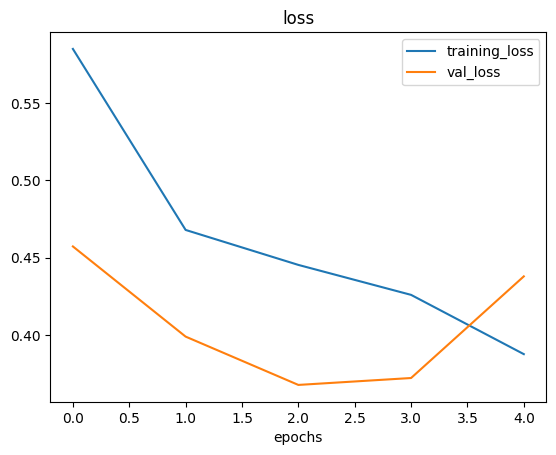

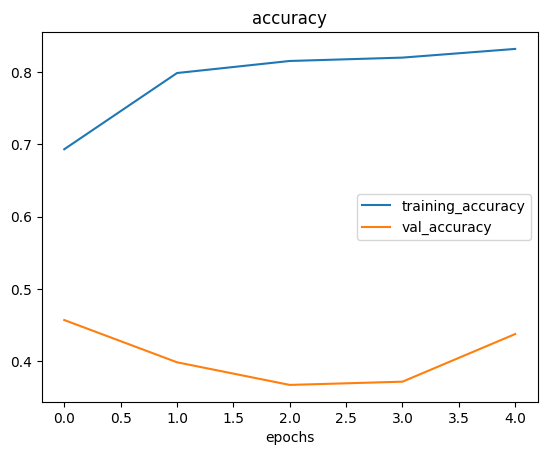

In [39]:
plot_loss_curves(history_5)

Reducing overfitting is known as *Regularization*

## Data Augumentation

In [40]:
# Create ImageDataGenerator training instance with data augumentation
train_datagen_augumentation = ImageDataGenerator(rescale=1/255.,         
                                                 rotation_range=0.2, # how much do you want to rotate an image ?
                                                 shear_range=0.2,   # how much do you want to shear an image ?
                                                 zoom_range=0.2,    # zoom in randomly on an image
                                                 width_shift_range=0.2, # move your image around on the x-axis
                                                 height_shift_range=0.3, # move your image around on the y-axis
                                                 horizontal_flip=True) # do you want to flip ?

# Create ImageDataGenerator without data augumentation
train_datagen = ImageDataGenerator(rescale=1/255.)

# Create ImageDataGenerator without data augumentation for the test data    
test_datagen = ImageDataGenerator(rescale=1/255.)

Data augumentation is the process of altering our training data , leading it to have more diversity and in turn allowing our model to learn more generalizable (hopefully) patterns .
Altering might mean adjusting the rotation of an image , flipping , cropping it or something similar.

In [41]:
# Import data and augument it from training directory
print("Augumented training data")
train_data_augumented = train_datagen_augumentation.flow_from_directory(train_dir,
                                                                        target_size=(244,244),
                                                                        batch_size=32,
                                                                        class_mode="binary",
                                                                        shuffle=False)

# Create non augumented data batches 
print("Non-augumented training data")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(244,244),
                                               batch_size=32,
                                               class_mode="binary",
                                               shuffle=False)

# Create non-augumented test data batches
print("Non-augumented test data :")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(244,244),
                                             batch_size=32,
                                             class_mode="binary",
                                             shuffle=False)


Augumented training data
Found 1500 images belonging to 2 classes.
Non-augumented training data
Found 1500 images belonging to 2 classes.
Non-augumented test data :
Found 500 images belonging to 2 classes.


In [42]:
# Get sample data batches
images , labels = next(train_data)
augumented_images , augumented_labels = next(train_data_augumented) # note : labels aren't augumented (only data - images)

showing image number : 22


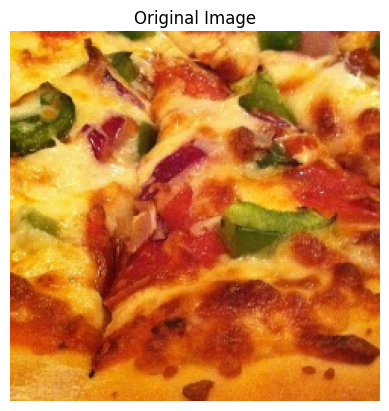

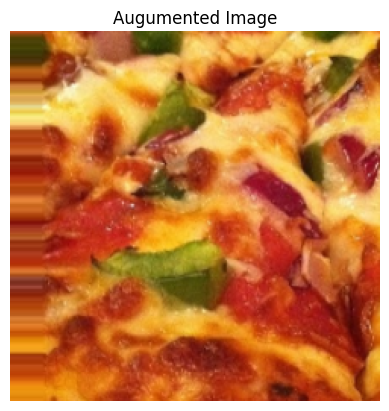

In [43]:
# Show original image and augumented image
import random 
random_number = random.randint(0, 32) # our batch size are 32

print(f"showing image number : {random_number}")
plt.imshow(images[random_number])
plt.title("Original Image")
plt.axis(False)
plt.figure()
plt.imshow(augumented_images[random_number])
plt.title("Augumented Image")
plt.axis(False);

In [44]:
# Create a model for our augumented data 
model_6 = Sequential([
    Conv2D(10 , 3 , activation="relu"),
    MaxPool2D(pool_size=2),
    Conv2D(10 , 3 , activation="relu"),
    MaxPool2D(),
    Conv2D(10 , 3 , activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1 , activation="sigmoid")
])

# Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# Fit the model
history_6 = model_6.fit(train_data_augumented, # fitting model_6 on augumented training data
                        epochs=5,
                        steps_per_epoch=len(train_data_augumented),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 520ms/step - accuracy: 0.5971 - loss: 0.7568 - val_accuracy: 0.6180 - val_loss: 0.6699
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 481ms/step - accuracy: 0.5819 - loss: 0.6736 - val_accuracy: 0.6140 - val_loss: 0.6745
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 477ms/step - accuracy: 0.5760 - loss: 0.6836 - val_accuracy: 0.6220 - val_loss: 0.6410
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 482ms/step - accuracy: 0.5643 - loss: 0.6843 - val_accuracy: 0.6660 - val_loss: 0.6830
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 477ms/step - accuracy: 0.6158 - loss: 0.6857 - val_accuracy: 0.6760 - val_loss: 0.6673


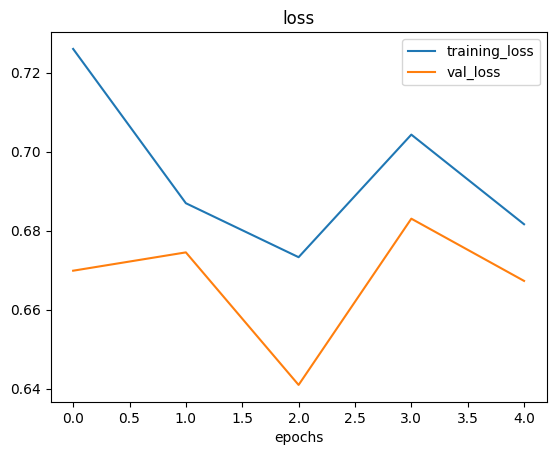

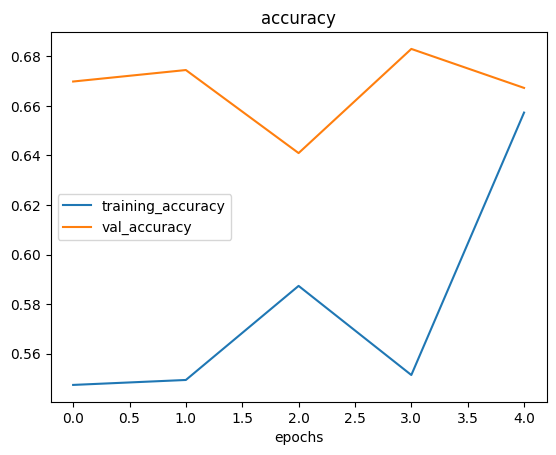

In [45]:
# Check our models training curves 
plot_loss_curves(history_6)

In [46]:
# Import data augumented it and shuffle from training directory 
train_data_augumented_shuffled = train_datagen_augumentation.flow_from_directory(train_dir,
                                                                                 target_size=(244,244),
                                                                                 class_mode="binary",
                                                                                 batch_size=32,
                                                                                 shuffle=True) # shuffle data this time

Found 1500 images belonging to 2 classes.


In [47]:
# Create the model (same as model_5 and model_6)
model_7 = Sequential([
    Conv2D(10, 3 , activation="relu" , input_shape=(244,244,3)),
    MaxPool2D(),
    Conv2D(10 , 3 , activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3 , activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1 , activation="sigmoid")
])

# Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# Fit the model
history_7 = model_7.fit(train_data_augumented_shuffled ,  # we are fitting on augumented and shuffled data now
                        epochs=5,
                        steps_per_epoch=len(train_data_augumented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 515ms/step - accuracy: 0.5814 - loss: 0.6663 - val_accuracy: 0.6920 - val_loss: 0.5544
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 477ms/step - accuracy: 0.6933 - loss: 0.5710 - val_accuracy: 0.7880 - val_loss: 0.4352
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 473ms/step - accuracy: 0.7459 - loss: 0.5138 - val_accuracy: 0.8200 - val_loss: 0.4050
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 478ms/step - accuracy: 0.7653 - loss: 0.4941 - val_accuracy: 0.8460 - val_loss: 0.3528
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 476ms/step - accuracy: 0.7748 - loss: 0.4733 - val_accuracy: 0.8600 - val_loss: 0.3508


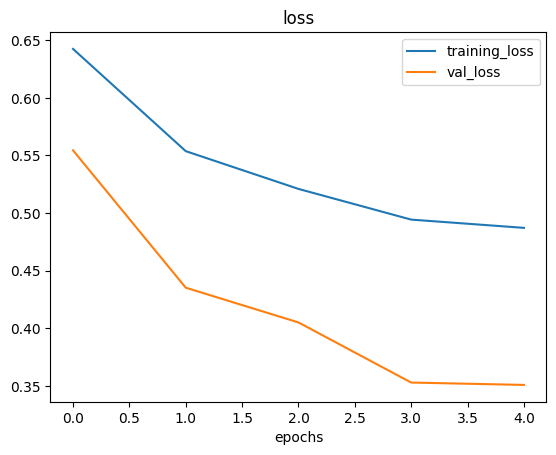

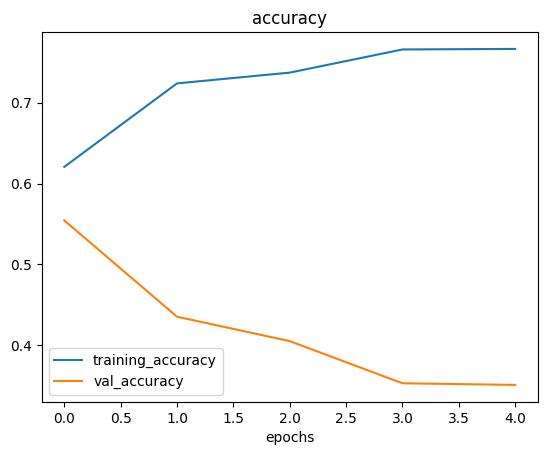

In [48]:
# Plot loss curves 
plot_loss_curves(history_7)

To continue to improve our model :

* Increase the number of model layers (e.g add more `Conv2D / maxPool2D` layers )
* Increase the number of filters in each convolutional layer (e.g from 10 to 32 or even 64)
* Train for longer (more epochs)
* Find an ideal learning rate
* Get more data (give the model more opportunities to learn)
* Use **Transfer Learning** to leverage what another image model has learn and adjust it for our own use cases 

In [49]:
# Making a prediction with our trained model on our own custom data

# Classes we're working with 
print(class_names)

['pizza' 'steak']


In [50]:
# View our example image
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-steak.jpeg
steak = mpimg.imread("03-steak.jpeg")

--2026-01-12 17:20:03--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg’

03-steak.jpeg       100%[===================>]   1.89M  --.-KB/s    in 0.02s   

2026-01-12 17:20:04 (116 MB/s) - ‘03-steak.jpeg’ saved [1978213/1978213]



(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

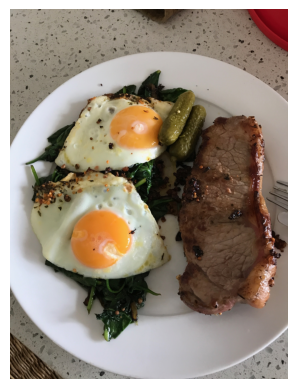

In [51]:
plt.imshow(steak)
plt.axis(False)

In [52]:
# Check the shape of our image
steak.shape

(4032, 3024, 3)

In [53]:
steak 

array([[[162, 158, 149],
        [163, 159, 150],
        [166, 162, 153],
        ...,
        [136,  17,  23],
        [140,  21,  27],
        [140,  21,  27]],

       [[164, 160, 151],
        [164, 160, 151],
        [164, 160, 151],
        ...,
        [133,  14,  20],
        [134,  15,  21],
        [137,  18,  24]],

       [[166, 162, 153],
        [165, 161, 152],
        [163, 159, 150],
        ...,
        [136,  17,  23],
        [134,  15,  21],
        [136,  17,  23]],

       ...,

       [[154, 132, 111],
        [142, 121, 100],
        [101,  80,  59],
        ...,
        [164, 155, 148],
        [152, 141, 135],
        [140, 129, 123]],

       [[141, 119,  96],
        [138, 118,  94],
        [106,  85,  64],
        ...,
        [158, 147, 141],
        [142, 131, 125],
        [138, 127, 121]],

       [[148, 126, 102],
        [148, 128, 103],
        [114,  93,  72],
        ...,
        [153, 142, 136],
        [138, 127, 121],
        [143, 132, 126]]

In [54]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename , img_shape=244):
    """
        Reads an image from filename , turns it into a tensor and reshape it to (img_shape , img_shape , colour_channels). 
    """
    
    # Read in the image 
    img = tf.io.read_file(filename)
    
    # Decode the read file into a tensor 
    img = tf.image.decode_image(img)
    
    # Resize the image
    img = tf.image.resize(img , size=[img_shape,img_shape])
    
    # Rescale the image (get all values between 0 and 1)
    img = img/255.
    
    return img    

In [55]:
steak_reshaped = load_and_prep_image("03-steak.jpeg")

steak_reshaped

<tf.Tensor: shape=(244, 244, 3), dtype=float32, numpy=
array([[[0.62829334, 0.61260706, 0.5694698 ],
        [0.6673293 , 0.6408105 , 0.5997305 ],
        [0.6288645 , 0.61317825, 0.56611943],
        ...,
        [0.5279978 , 0.05740957, 0.09270369],
        [0.5383952 , 0.07957173, 0.11094428],
        [0.5240058 , 0.07302541, 0.1004764 ]],

       [[0.6354672 , 0.6197809 , 0.57664365],
        [0.6364191 , 0.62073284, 0.573674  ],
        [0.6332691 , 0.6175828 , 0.570524  ],
        ...,
        [0.5269163 , 0.05632809, 0.09162221],
        [0.5549276 , 0.08433936, 0.11963347],
        [0.52707314, 0.06824964, 0.09962219]],

       [[0.6360334 , 0.62034714, 0.5732883 ],
        [0.6626118 , 0.6390824 , 0.59202355],
        [0.65419877, 0.6377974 , 0.5907386 ],
        ...,
        [0.5446726 , 0.07408439, 0.111761  ],
        [0.53613055, 0.07730698, 0.10867953],
        [0.5340747 , 0.06348649, 0.0987806 ]],

       ...,

       [[0.56892025, 0.4865673 , 0.37522048],
        [0.06

In [56]:
pred = model_7.predict(tf.expand_dims(steak_reshaped , axis=0))
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step


array([[0.83798176]], dtype=float32)

In [57]:
# We can index the predicted class by rounding the prediction probability and indexing it on the class names
pred_class = class_names[int(tf.round(pred))]
print(pred_class)

steak


In [58]:
def pred_and_plot(model , filename , class_names=class_names) :
    """
     Imports an image located at filename , makes a prediction with model 
     and plots the image with the predicted class as the title .
    """
    
    # Import the target image and preprocess it 
    img = load_and_prep_image(filename)
    
    # Make a prediction 
    pred = model.predict(tf.expand_dims(img , axis=0))
    
    # Add in logic for multi-class
    if len(pred[0]) > 1 :
        pred_class = class_names[tf.argmax(pred[0])]
    else :
        # Get the predicted class 
        pred_class = class_names[int(tf.round(pred[0]))]
        
    
    # Plot the image and predicted class 
    plt.imshow(img)
    plt.title(f"Prediction : {pred_class}")
    plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


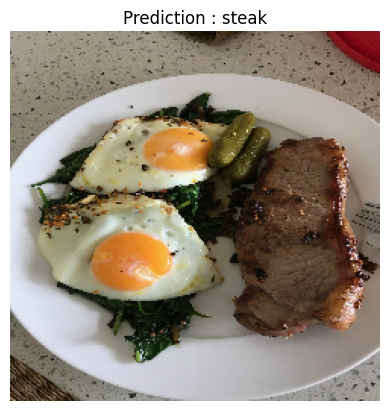

In [59]:
# Test our model on a custom image 
pred_and_plot(model_7 , "03-steak.jpeg")

In [60]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-pizza-dad.jpeg

--2026-01-12 17:20:10--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874848 (2.7M) [image/jpeg]
Saving to: ‘03-pizza-dad.jpeg’

03-pizza-dad.jpeg   100%[===================>]   2.74M  --.-KB/s    in 0.01s   

2026-01-12 17:20:11 (258 MB/s) - ‘03-pizza-dad.jpeg’ saved [2874848/2874848]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


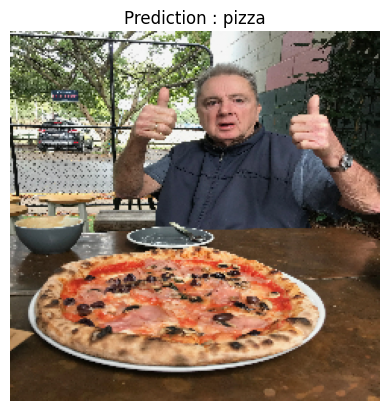

In [61]:
pred_and_plot(model_7 , "03-pizza-dad.jpeg")

### Multi-class Image Classification

1. Understand the data
2. Preprocess the data (get it ready for a model)
3. Create a model (start with a baseline)
4. Fit the model (overfit it to make sure it works)
5. Evaluate the model
6. Adjust different hyperparameters and improve the model (try to beat baseline / reduce overfitting)
7. Repeat until satisfied

In [62]:
import zipfile
# Import our data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

# unzip our data
zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip" , "r")
zip_ref.extractall()
zip_ref.close()

--2026-01-12 17:20:12--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.194.207, 142.251.10.207, 142.251.12.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.194.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  21.9MB/s    in 23s     

2026-01-12 17:20:35 (21.3 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [63]:
import os

# Walk through 10 classes of food image data
for dirpath , dirnames , filenames in os.walk("10_food_classes_all_data") :
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in `{dirpath}` .")

There are 2 directories and 0 images in `10_food_classes_all_data` .
There are 10 directories and 0 images in `10_food_classes_all_data/test` .
There are 0 directories and 250 images in `10_food_classes_all_data/test/hamburger` .
There are 0 directories and 250 images in `10_food_classes_all_data/test/sushi` .
There are 0 directories and 250 images in `10_food_classes_all_data/test/grilled_salmon` .
There are 0 directories and 250 images in `10_food_classes_all_data/test/chicken_curry` .
There are 0 directories and 250 images in `10_food_classes_all_data/test/steak` .
There are 0 directories and 250 images in `10_food_classes_all_data/test/chicken_wings` .
There are 0 directories and 250 images in `10_food_classes_all_data/test/ice_cream` .
There are 0 directories and 250 images in `10_food_classes_all_data/test/ramen` .
There are 0 directories and 250 images in `10_food_classes_all_data/test/pizza` .
There are 0 directories and 250 images in `10_food_classes_all_data/test/fried_rice` 

In [ ]:
# Setup the train and test directories 
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

In [65]:
# Get the subdirectories (these are our class names)
import pathlib 
import numpy as np 

data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob("*")]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


Image shape: (382, 512, 3)


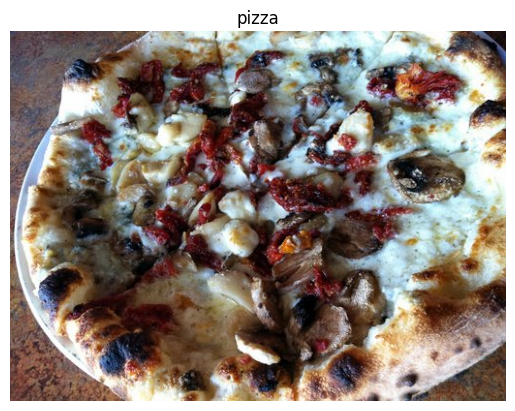

In [66]:
# Visualise our data
import random 
img = view_random_image(target_dir=train_dir,
                        target_class=random.choice(class_names))

In [67]:
# Preprocess the data 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 

# Rescale 
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)


# Load data in from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(244,244),
                                               batch_size=32,
                                               class_mode="categorical")

test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(244,244),
                                             batch_size=32,
                                             class_mode="categorical")

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


Create a model (start with a baseline)

In [68]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPool2D , Flatten , Dense

# Create our model (very similar to previous models but actually the same as CNN explainer website)
model_8 = Sequential([
    Conv2D(10 , 3 , input_shape=(244 , 244 , 3)),
    Activation(activation="relu"),
    Conv2D(10 , 3 , activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3 , activation="relu"),
    Conv2D(10, 3 , activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10 , activation="softmax")
])

# Compile the model
model_8.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [69]:
# Fit a model
history_8 = model_8.fit(train_data , # now 10 different classes 
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 32s 124ms/step - accuracy: 0.1707 - loss: 2.2322 - val_accuracy: 0.2892 - val_loss: 2.0205
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.3727 - loss: 1.8413 - val_accuracy: 0.3140 - val_loss: 1.9719
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 127ms/step - accuracy: 0.6371 - loss: 1.1484 - val_accuracy: 0.2740 - val_loss: 2.3906
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - accuracy: 0.8892 - loss: 0.3844 - val_accuracy: 0.2676 - val_loss: 3.3961
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - accuracy: 0.9732 - loss: 0.1147 - val_accuracy: 0.2636 - val_loss: 5.0698


In [70]:
# Evaluate the model
model_8.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.2694 - loss: 5.0677


[5.069825172424316, 0.2635999917984009]

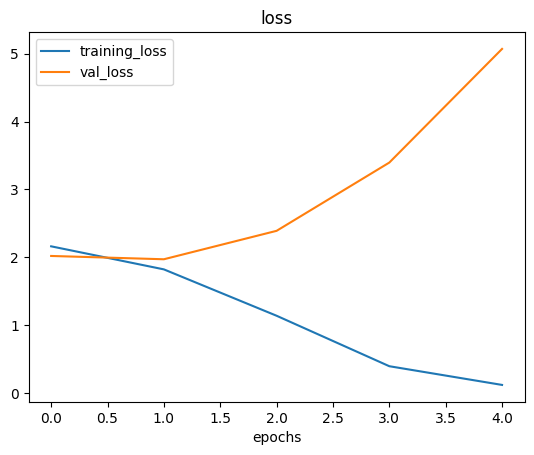

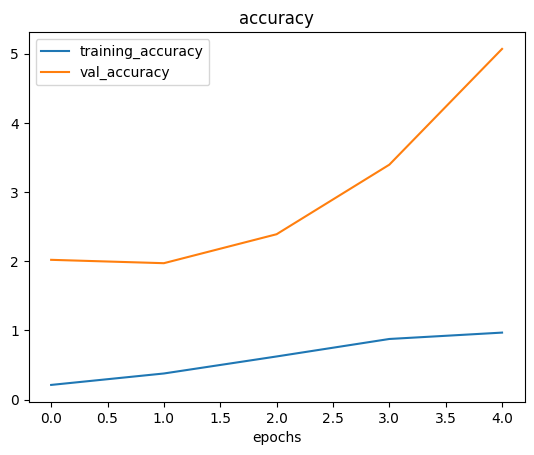

In [71]:
# Check out the model's loss curves on the 10 classes
plot_loss_curves(history_8)

What do these loss curves tell us ? 

Well .. it seems our model is **overfitting** the training set quite badly ..
in other words , it's getting great results on the training data but fails to generalize well to unseen data 
and performs poorly on the test dataset .

Next step : Adjust the model hyperparameters

Let's try and fix overfitting by ...

* **Get more data** - having more data gives a model more opportunity to learn diverse patterns ...
* **Simplify the model** - if our current model is overfitting the data , it may be too complicated of a model , one way to simplify a model is to reduce number of hidden layers
* **Use data augumentation** - modify the images
* **Use Trandfer Learning** - tranfer learning leverages the patterns another model has learned on similar data to your own and allows you to use those patterns on your own dataset .

In [72]:
model_8.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 242, 242, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 242, 242, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 240, 240, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 120, 120, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 118, 118, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 116, 116, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 58, 58, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 33640)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │       336,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,018,262 (3.88 MB)

 Trainable params: 339,420 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 678,842 (2.59 MB)

In [73]:
# Let's try to remove 2 conv layers 
# Create our model (very similar to previous models but actually the same as CNN explainer website)
model_9 = Sequential([
    Conv2D(10 , 3 , activation="relu" , input_shape=(244 , 244 , 3)),
    MaxPool2D(),
    Conv2D(10, 3 , activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10 , activation="softmax")
])

# Compile the model
model_9.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [74]:
history_9 = model_9.fit(train_data , # now 10 different classes 
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 31s 123ms/step - accuracy: 0.2105 - loss: 2.4155 - val_accuracy: 0.3168 - val_loss: 1.9376
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 106ms/step - accuracy: 0.3971 - loss: 1.7670 - val_accuracy: 0.3340 - val_loss: 1.9207
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.5824 - loss: 1.3012 - val_accuracy: 0.3132 - val_loss: 1.9673
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.7872 - loss: 0.7489 - val_accuracy: 0.3260 - val_loss: 2.4009
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - accuracy: 0.9161 - loss: 0.3316 - val_accuracy: 0.3060 - val_loss: 2.8325


### Trying to reduce overfitting with data augumentation

Let's try and improve our model's results by using augumented training data ...

Ideally , we want to :
* Reduce overfitting (get the train and validation loss curves closer) .
* Improve validation accuracy 



In [75]:
# Create an augumented data generator instance
train_datagen_augumented = ImageDataGenerator(rescale=1/255.,
                                              rotation_range=0.2,
                                              width_shift_range=0.2,
                                              height_shift_range=0.2,
                                              zoom_range=0.2,
                                              horizontal_flip=True)

train_data_augumented = train_datagen_augumented.flow_from_directory(train_dir,
                                                                     target_size=(244,244),
                                                                     batch_size=32,
                                                                     class_mode="categorical")

Found 7500 images belonging to 10 classes.


In [76]:
# Create our model with data augumentation
model_10 = tf.keras.models.clone_model(model_8)

# Compiled the cloned model (using the same setup as previous  models)
model_10.compile(loss="categorical_crossentropy",
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

In [77]:
# Fit the model 
history_10 = model_10.fit(train_data_augumented,
                          epochs=5,
                          steps_per_epoch=len(train_data_augumented),
                          validation_data=test_data,
                          validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 118s 489ms/step - accuracy: 0.1481 - loss: 2.2695 - val_accuracy: 0.2640 - val_loss: 2.0432
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 114s 484ms/step - accuracy: 0.2464 - loss: 2.1134 - val_accuracy: 0.3072 - val_loss: 1.9679
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 113s 482ms/step - accuracy: 0.2687 - loss: 2.0527 - val_accuracy: 0.3264 - val_loss: 1.9481
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 113s 481ms/step - accuracy: 0.2961 - loss: 2.0122 - val_accuracy: 0.3616 - val_loss: 1.8538
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 114s 482ms/step - accuracy: 0.3067 - loss: 1.9745 - val_accuracy: 0.3484 - val_loss: 1.9152


In [78]:
model_8.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.2774 - loss: 4.8942


[5.069823741912842, 0.2635999917984009]

In [79]:
model_10.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.3456 - loss: 1.8900


[1.9152404069900513, 0.3483999967575073]

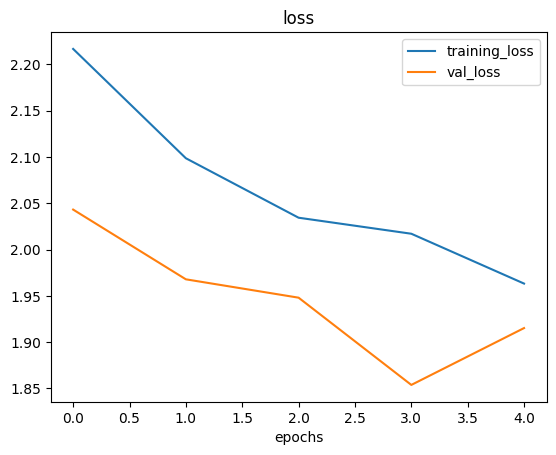

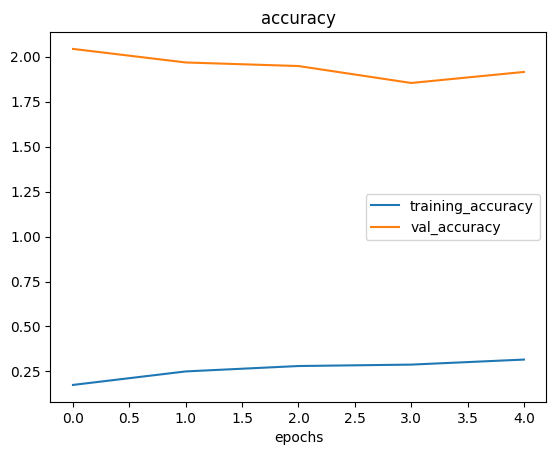

In [80]:
# Check out our model trained on augumented data's loss curves
plot_loss_curves(history_10)

That looks much better 

In [81]:
# Make a prediction 
class_names

array(['chicken_curry', 'chicken_wings', 'fried_rice', 'grilled_salmon',
       'hamburger', 'ice_cream', 'pizza', 'ramen', 'steak', 'sushi'],
      dtype='<U14')

In [82]:
# Download some custom images
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-sushi.jpeg
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-hamburger.jpeg

--2026-01-12 17:35:19--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-sushi.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1725178 (1.6M) [image/jpeg]
Saving to: ‘03-sushi.jpeg’

03-sushi.jpeg       100%[===================>]   1.64M  --.-KB/s    in 0.006s  

2026-01-12 17:35:20 (281 MB/s) - ‘03-sushi.jpeg’ saved [1725178/1725178]

--2026-01-12 17:35:20--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-hamburger.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent,

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step


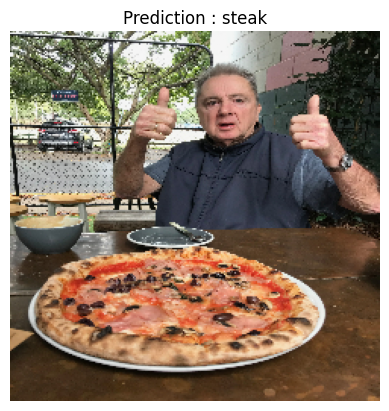

In [83]:
# Make a prediction using model_10
pred_and_plot(model=model_10 , filename="03-pizza-dad.jpeg" , class_names=class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


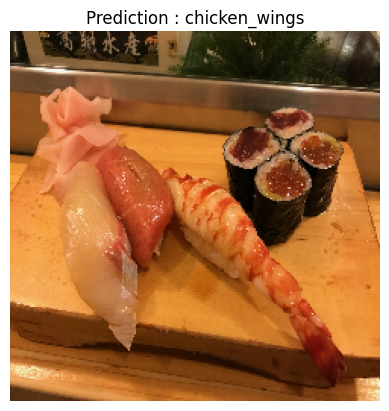

In [84]:
pred_and_plot(model_10 , "03-sushi.jpeg" , class_names=class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


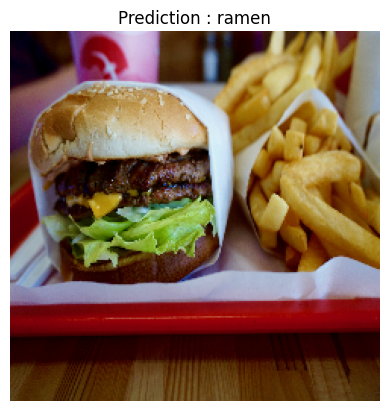

In [85]:
pred_and_plot(model_10 , "03-hamburger.jpeg" , class_names)

Our model is not performing very well . In the next project I will use transfer learning to improve it . 

Next : save the model for feature use .

In [86]:
# Save model 

model_10.save("saved_trained_model10_multiclass_food.keras")